## Load packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Model definition

In [2]:
# Transition model
# Rows: from states (short_pile_t0, long_pile_t0, short_pile_t1, long_pile_t1)
# Columns: to states (short_pile_t0, long_pile_t0, short_pile_t1, long_pile_t1)
transition_model = np.array([
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0],
    [0.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 1.0]
])

# Observation model (no info)
# Rows: observations (40ft, 45ft, 50ft)
# Columns: states (short_pile_t0, long_pile_t0, short_pile_t1, long_pile_t1)
observation_model_no_info = np.array([
    [0.5, 0.5, 0.5, 0.5],
    [0.0, 0.0, 0.0, 0.0],
    [0.5, 0.5, 0.5, 0.5]
])

# Observation model (drill)
# Rows: observations (40ft, 45ft, 50ft)
# Columns: states (short_pile_t0, long_pile_t0, short_pile_t1, long_pile_t1)
observation_model_drill = np.array([
    [1.0, 0.0, 1.0, 0.0],
    [0.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 1.0]
])

# Observation model (sonic)
# Rows: observations (40ft, 45ft, 50ft)
# Columns: states (short_pile_t0, long_pile_t0, short_pile_t1, long_pile_t1)
observation_model_sonic = np.array([
    [0.6, 0.1, 0.6, 0.1],
    [0.3, 0.2, 0.3, 0.2],
    [0.1, 0.7, 0.1, 0.7]
])

# Reward model 
# Rows: actions (order_short_no_info, order_short_drill, order_short_sonic, order_long_no_info, order_long_drill, order_long_sonic)
# Columns: states (short_pile_t0, long_pile_t0, short_pile_t1, long_pile_t1)
reward_model = np.array([
    [0.0, 0.0, 0.0, -400.0],
    [-50.0, -50.0, -50.0, -450.0],
    [-20.0, -20.0, -20.0, -420.0],
    [0.0, 0.0, -100.0, 0.0],
    [-50.0, -50.0, -150.0, -50.0],
    [-20.0, -20.0, -120.0, -20.0],
])

## Time step: $t_H$

In [3]:
# alpha timestep_action_index
alpha_2_0_0 = np.array([0.0, 0.0, 0.0, 0.0]) # terminal alpha-vector

## Time step: $t_1$

In [4]:
alpha_1_0_0 = reward_model[0]
aloha_1_0_1 = reward_model[1]
alpha_1_0_2 = reward_model[2]
alpha_1_0_3 = reward_model[3]
alpha_1_0_4 = reward_model[4]
alpha_1_0_5 = reward_model[5]

print("Alpha vectors at timestep 1:")
print("Action 0 (order_short_no_info):", alpha_1_0_0)
print("Action 1 (order_short_drill):", aloha_1_0_1)
print("Action 2 (order_short_sonic):", alpha_1_0_2)
print("Action 3 (order_long_no_info):", alpha_1_0_3)
print("Action 4 (order_long_drill):", alpha_1_0_4)
print("Action 5 (order_long_sonic):", alpha_1_0_5)

print("We only keep the alpha-vectors that are not dominated by others.")
# After analysis, we find that only the following alpha-vectors are kept:
print("Action 0 (order_short_no_info) alpha_1_0_0:", alpha_1_0_0)
print("Action 3 (order_long_no_info) alpha_1_0_3:", alpha_1_0_3)

alpha_vectors_t1 = []
associated_actions_t1 = []
alpha_vectors_t1.append(alpha_1_0_0[-2:])
associated_actions_t1.append("order_short_no_info")
alpha_vectors_t1.append(alpha_1_0_3[-2:])
associated_actions_t1.append("order_long_no_info")

Alpha vectors at timestep 1:
Action 0 (order_short_no_info): [   0.    0.    0. -400.]
Action 1 (order_short_drill): [ -50.  -50.  -50. -450.]
Action 2 (order_short_sonic): [ -20.  -20.  -20. -420.]
Action 3 (order_long_no_info): [   0.    0. -100.    0.]
Action 4 (order_long_drill): [ -50.  -50. -150.  -50.]
Action 5 (order_long_sonic): [ -20.  -20. -120.  -20.]
We only keep the alpha-vectors that are not dominated by others.
Action 0 (order_short_no_info) alpha_1_0_0: [   0.    0.    0. -400.]
Action 3 (order_long_no_info) alpha_1_0_3: [   0.    0. -100.    0.]


## Time step: $t_0$

In [5]:
## Store alpha-vectors at timestep 0 for each action
alpha_vectors = []
associated_actions = []

### Action (0): order_short_no_info

In [6]:
alp_0_0 = observation_model_no_info[0] * alpha_1_0_0
alp_0_0 = transition_model @ alp_0_0 

alp_0_1 = observation_model_no_info[1] * alpha_1_0_0
alp_0_1 = transition_model @ alp_0_1 

alp_0_2 = observation_model_no_info[2] * alpha_1_0_0
alp_0_2 = transition_model @ alp_0_2 

alp_3_0 = observation_model_no_info[0] * alpha_1_0_3
alp_3_0 = transition_model @ alp_3_0 

alp_3_1 = observation_model_no_info[1] * alpha_1_0_3
alp_3_1 = transition_model @ alp_3_1 

alp_3_2 = observation_model_no_info[2] * alpha_1_0_3
alp_3_2 = transition_model @ alp_3_2 

alpha_0_0_0 = reward_model[0] + alp_0_0 + alp_0_1 + alp_0_2
alpha_0_0_1 = reward_model[0] + alp_0_0 + alp_0_1 + alp_3_2
alpha_0_0_2 = reward_model[0] + alp_0_0 + alp_3_1 + alp_0_2
alpha_0_0_3 = reward_model[0] + alp_0_0 + alp_3_1 + alp_3_2
alpha_0_0_4 = reward_model[0] + alp_3_0 + alp_0_1 + alp_0_2
alpha_0_0_5 = reward_model[0] + alp_3_0 + alp_0_1 + alp_3_2
alpha_0_0_6 = reward_model[0] + alp_3_0 + alp_3_1 + alp_0_2
alpha_0_0_7 = reward_model[0] + alp_3_0 + alp_3_1 + alp_3_2

print("Alpha vectors at timestep 0 for action order_short_no_info:")
print("Combination 0:", alpha_0_0_0)
print("Combination 1:", alpha_0_0_1)
print("Combination 2:", alpha_0_0_2)
print("Combination 3:", alpha_0_0_3)
print("Combination 4:", alpha_0_0_4)
print("Combination 5:", alpha_0_0_5)
print("Combination 6:", alpha_0_0_6)
print("Combination 7:", alpha_0_0_7)

alpha_vectors.append(alpha_0_0_0[:2])
associated_actions.append("order_short_no_info")
alpha_vectors.append(alpha_0_0_1[:2])
associated_actions.append("order_short_no_info")
alpha_vectors.append(alpha_0_0_5[:2])
associated_actions.append("order_short_no_info")

Alpha vectors at timestep 0 for action order_short_no_info:
Combination 0: [   0. -400.    0. -800.]
Combination 1: [ -50. -200.  -50. -600.]
Combination 2: [   0. -400.    0. -800.]
Combination 3: [ -50. -200.  -50. -600.]
Combination 4: [ -50. -200.  -50. -600.]
Combination 5: [-100.    0. -100. -400.]
Combination 6: [ -50. -200.  -50. -600.]
Combination 7: [-100.    0. -100. -400.]


### Action (1): order_short_drill

In [7]:
alp_0_0 = observation_model_drill[0] * alpha_1_0_0
alp_0_0 = transition_model @ alp_0_0 

alp_0_1 = observation_model_drill[1] * alpha_1_0_0
alp_0_1 = transition_model @ alp_0_1 

alp_0_2 = observation_model_drill[2] * alpha_1_0_0
alp_0_2 = transition_model @ alp_0_2 

alp_3_0 = observation_model_drill[0] * alpha_1_0_3
alp_3_0 = transition_model @ alp_3_0 

alp_3_1 = observation_model_drill[1] * alpha_1_0_3
alp_3_1 = transition_model @ alp_3_1 

alp_3_2 = observation_model_drill[2] * alpha_1_0_3
alp_3_2 = transition_model @ alp_3_2 

alpha_0_1_0 = reward_model[1] + alp_0_0 + alp_0_1 + alp_0_2
alpha_0_1_1 = reward_model[1] + alp_0_0 + alp_0_1 + alp_3_2
alpha_0_1_2 = reward_model[1] + alp_0_0 + alp_3_1 + alp_0_2
alpha_0_1_3 = reward_model[1] + alp_0_0 + alp_3_1 + alp_3_2
alpha_0_1_4 = reward_model[1] + alp_3_0 + alp_0_1 + alp_0_2
alpha_0_1_5 = reward_model[1] + alp_3_0 + alp_0_1 + alp_3_2
alpha_0_1_6 = reward_model[1] + alp_3_0 + alp_3_1 + alp_0_2
alpha_0_1_7 = reward_model[1] + alp_3_0 + alp_3_1 + alp_3_2

print("Alpha vectors at timestep 0 for action order_short_drill:")
print("Combination 0:", alpha_0_1_0)
print("Combination 1:", alpha_0_1_1)
print("Combination 2:", alpha_0_1_2)
print("Combination 3:", alpha_0_1_3)
print("Combination 4:", alpha_0_1_4)
print("Combination 5:", alpha_0_1_5)
print("Combination 6:", alpha_0_1_6)
print("Combination 7:", alpha_0_1_7)

alpha_vectors.append(alpha_0_1_1[:2])
associated_actions.append("order_short_drill")

Alpha vectors at timestep 0 for action order_short_drill:
Combination 0: [ -50. -450.  -50. -850.]
Combination 1: [ -50.  -50.  -50. -450.]
Combination 2: [ -50. -450.  -50. -850.]
Combination 3: [ -50.  -50.  -50. -450.]
Combination 4: [-150. -450. -150. -850.]
Combination 5: [-150.  -50. -150. -450.]
Combination 6: [-150. -450. -150. -850.]
Combination 7: [-150.  -50. -150. -450.]


### Action (2): order_short_sonic

In [8]:
alp_0_0 = observation_model_sonic[0] * alpha_1_0_0
alp_0_0 = transition_model @ alp_0_0 

alp_0_1 = observation_model_sonic[1] * alpha_1_0_0
alp_0_1 = transition_model @ alp_0_1 

alp_0_2 = observation_model_sonic[2] * alpha_1_0_0
alp_0_2 = transition_model @ alp_0_2 

alp_3_0 = observation_model_sonic[0] * alpha_1_0_3
alp_3_0 = transition_model @ alp_3_0 

alp_3_1 = observation_model_sonic[1] * alpha_1_0_3
alp_3_1 = transition_model @ alp_3_1 

alp_3_2 = observation_model_sonic[2] * alpha_1_0_3
alp_3_2 = transition_model @ alp_3_2 

alpha_0_2_0 = reward_model[2] + alp_0_0 + alp_0_1 + alp_0_2
alpha_0_2_1 = reward_model[2] + alp_0_0 + alp_0_1 + alp_3_2
alpha_0_2_2 = reward_model[2] + alp_0_0 + alp_3_1 + alp_0_2
alpha_0_2_3 = reward_model[2] + alp_0_0 + alp_3_1 + alp_3_2
alpha_0_2_4 = reward_model[2] + alp_3_0 + alp_0_1 + alp_0_2
alpha_0_2_5 = reward_model[2] + alp_3_0 + alp_0_1 + alp_3_2
alpha_0_2_6 = reward_model[2] + alp_3_0 + alp_3_1 + alp_0_2
alpha_0_2_7 = reward_model[2] + alp_3_0 + alp_3_1 + alp_3_2

print("Alpha vectors at timestep 0 for action order_short_sonic:")
print("Combination 0:", alpha_0_2_0)
print("Combination 1:", alpha_0_2_1)
print("Combination 2:", alpha_0_2_2)
print("Combination 3:", alpha_0_2_3)
print("Combination 4:", alpha_0_2_4)
print("Combination 5:", alpha_0_2_5)
print("Combination 6:", alpha_0_2_6)
print("Combination 7:", alpha_0_2_7)

alpha_vectors.append(alpha_0_2_0[:2])
associated_actions.append("order_short_sonic")
alpha_vectors.append(alpha_0_2_1[:2])
associated_actions.append("order_short_sonic")
alpha_vectors.append(alpha_0_2_3[:2])
associated_actions.append("order_short_sonic")
alpha_vectors.append(alpha_0_2_7[:2])
associated_actions.append("order_short_sonic")

Alpha vectors at timestep 0 for action order_short_sonic:
Combination 0: [ -20. -420.  -20. -820.]
Combination 1: [ -30. -140.  -30. -540.]
Combination 2: [ -50. -340.  -50. -740.]
Combination 3: [ -60.  -60.  -60. -460.]
Combination 4: [ -80. -380.  -80. -780.]
Combination 5: [ -90. -100.  -90. -500.]
Combination 6: [-110. -300. -110. -700.]
Combination 7: [-120.  -20. -120. -420.]


### Action (3): order_long_no_info

In [9]:
alp_0_0 = observation_model_no_info[0] * alpha_1_0_0
alp_0_0 = transition_model @ alp_0_0 

alp_0_1 = observation_model_no_info[1] * alpha_1_0_0
alp_0_1 = transition_model @ alp_0_1 

alp_0_2 = observation_model_no_info[2] * alpha_1_0_0
alp_0_2 = transition_model @ alp_0_2 

alp_3_0 = observation_model_no_info[0] * alpha_1_0_3
alp_3_0 = transition_model @ alp_3_0 

alp_3_1 = observation_model_no_info[1] * alpha_1_0_3
alp_3_1 = transition_model @ alp_3_1 

alp_3_2 = observation_model_no_info[2] * alpha_1_0_3
alp_3_2 = transition_model @ alp_3_2 

alpha_0_3_0 = reward_model[3] + alp_0_0 + alp_0_1 + alp_0_2
alpha_0_3_1 = reward_model[3] + alp_0_0 + alp_0_1 + alp_3_2
alpha_0_3_2 = reward_model[3] + alp_0_0 + alp_3_1 + alp_0_2
alpha_0_3_3 = reward_model[3] + alp_0_0 + alp_3_1 + alp_3_2
alpha_0_3_4 = reward_model[3] + alp_3_0 + alp_0_1 + alp_0_2
alpha_0_3_5 = reward_model[3] + alp_3_0 + alp_0_1 + alp_3_2
alpha_0_3_6 = reward_model[3] + alp_3_0 + alp_3_1 + alp_0_2
alpha_0_3_7 = reward_model[3] + alp_3_0 + alp_3_1 + alp_3_2

print("Alpha vectors at timestep 0 for action order_long_no_info:")
print("Combination 0:", alpha_0_3_0)
print("Combination 1:", alpha_0_3_1)
print("Combination 2:", alpha_0_3_2)
print("Combination 3:", alpha_0_3_3)
print("Combination 4:", alpha_0_3_4)
print("Combination 5:", alpha_0_3_5)
print("Combination 6:", alpha_0_3_6)
print("Combination 7:", alpha_0_3_7)

alpha_vectors.append(alpha_0_3_0[:2])
associated_actions.append("order_long_no_info")
alpha_vectors.append(alpha_0_3_1[:2])
associated_actions.append("order_long_no_info")
alpha_vectors.append(alpha_0_3_5[:2])
associated_actions.append("order_long_no_info")

Alpha vectors at timestep 0 for action order_long_no_info:
Combination 0: [   0. -400. -100. -400.]
Combination 1: [ -50. -200. -150. -200.]
Combination 2: [   0. -400. -100. -400.]
Combination 3: [ -50. -200. -150. -200.]
Combination 4: [ -50. -200. -150. -200.]
Combination 5: [-100.    0. -200.    0.]
Combination 6: [ -50. -200. -150. -200.]
Combination 7: [-100.    0. -200.    0.]


### Action (4): order_long_drill

In [10]:
alp_0_0 = observation_model_drill[0] * alpha_1_0_0
alp_0_0 = transition_model @ alp_0_0 

alp_0_1 = observation_model_drill[1] * alpha_1_0_0
alp_0_1 = transition_model @ alp_0_1 

alp_0_2 = observation_model_drill[2] * alpha_1_0_0
alp_0_2 = transition_model @ alp_0_2 

alp_3_0 = observation_model_drill[0] * alpha_1_0_3
alp_3_0 = transition_model @ alp_3_0 

alp_3_1 = observation_model_drill[1] * alpha_1_0_3
alp_3_1 = transition_model @ alp_3_1 

alp_3_2 = observation_model_drill[2] * alpha_1_0_3
alp_3_2 = transition_model @ alp_3_2 

alpha_0_4_0 = reward_model[4] + alp_0_0 + alp_0_1 + alp_0_2
alpha_0_4_1 = reward_model[4] + alp_0_0 + alp_0_1 + alp_3_2
alpha_0_4_2 = reward_model[4] + alp_0_0 + alp_3_1 + alp_0_2
alpha_0_4_3 = reward_model[4] + alp_0_0 + alp_3_1 + alp_3_2
alpha_0_4_4 = reward_model[4] + alp_3_0 + alp_0_1 + alp_0_2
alpha_0_4_5 = reward_model[4] + alp_3_0 + alp_0_1 + alp_3_2
alpha_0_4_6 = reward_model[4] + alp_3_0 + alp_3_1 + alp_0_2
alpha_0_4_7 = reward_model[4] + alp_3_0 + alp_3_1 + alp_3_2

print("Alpha vectors at timestep 0 for action order_long_drill:")
print("Combination 0:", alpha_0_4_0)
print("Combination 1:", alpha_0_4_1)
print("Combination 2:", alpha_0_4_2)
print("Combination 3:", alpha_0_4_3)
print("Combination 4:", alpha_0_4_4)
print("Combination 5:", alpha_0_4_5)
print("Combination 6:", alpha_0_4_6)
print("Combination 7:", alpha_0_4_7)

alpha_vectors.append(alpha_0_4_1[:2])
associated_actions.append("order_long_drill")

Alpha vectors at timestep 0 for action order_long_drill:
Combination 0: [ -50. -450. -150. -450.]
Combination 1: [ -50.  -50. -150.  -50.]
Combination 2: [ -50. -450. -150. -450.]
Combination 3: [ -50.  -50. -150.  -50.]
Combination 4: [-150. -450. -250. -450.]
Combination 5: [-150.  -50. -250.  -50.]
Combination 6: [-150. -450. -250. -450.]
Combination 7: [-150.  -50. -250.  -50.]


### Action (5): Order_long_sonic

In [11]:
alp_0_0 = observation_model_sonic[0] * alpha_1_0_0
alp_0_0 = transition_model @ alp_0_0 

alp_0_1 = observation_model_sonic[1] * alpha_1_0_0
alp_0_1 = transition_model @ alp_0_1 

alp_0_2 = observation_model_sonic[2] * alpha_1_0_0
alp_0_2 = transition_model @ alp_0_2 

alp_3_0 = observation_model_sonic[0] * alpha_1_0_3
alp_3_0 = transition_model @ alp_3_0 

alp_3_1 = observation_model_sonic[1] * alpha_1_0_3
alp_3_1 = transition_model @ alp_3_1 

alp_3_2 = observation_model_sonic[2] * alpha_1_0_3
alp_3_2 = transition_model @ alp_3_2 

alpha_0_5_0 = reward_model[5] + alp_0_0 + alp_0_1 + alp_0_2
alpha_0_5_1 = reward_model[5] + alp_0_0 + alp_0_1 + alp_3_2
alpha_0_5_2 = reward_model[5] + alp_0_0 + alp_3_1 + alp_0_2
alpha_0_5_3 = reward_model[5] + alp_0_0 + alp_3_1 + alp_3_2
alpha_0_5_4 = reward_model[5] + alp_3_0 + alp_0_1 + alp_0_2
alpha_0_5_5 = reward_model[5] + alp_3_0 + alp_0_1 + alp_3_2
alpha_0_5_6 = reward_model[5] + alp_3_0 + alp_3_1 + alp_0_2
alpha_0_5_7 = reward_model[5] + alp_3_0 + alp_3_1 + alp_3_2

print("Alpha vectors at timestep 0 for action order_long_sonic:")
print("Combination 0:", alpha_0_5_0)
print("Combination 1:", alpha_0_5_1)
print("Combination 2:", alpha_0_5_2)
print("Combination 3:", alpha_0_5_3)
print("Combination 4:", alpha_0_5_4)
print("Combination 5:", alpha_0_5_5)
print("Combination 6:", alpha_0_5_6)
print("Combination 7:", alpha_0_5_7)

alpha_vectors.append(alpha_0_5_0[:2])
associated_actions.append("order_long_sonic")
alpha_vectors.append(alpha_0_5_1[:2])
associated_actions.append("order_long_sonic")
alpha_vectors.append(alpha_0_5_3[:2])
associated_actions.append("order_long_sonic")
alpha_vectors.append(alpha_0_5_7[:2])
associated_actions.append("order_long_sonic")

Alpha vectors at timestep 0 for action order_long_sonic:
Combination 0: [ -20. -420. -120. -420.]
Combination 1: [ -30. -140. -130. -140.]
Combination 2: [ -50. -340. -150. -340.]
Combination 3: [ -60.  -60. -160.  -60.]
Combination 4: [ -80. -380. -180. -380.]
Combination 5: [ -90. -100. -190. -100.]
Combination 6: [-110. -300. -210. -300.]
Combination 7: [-120.  -20. -220.  -20.]


In [12]:
# Stack alpha-vectors for plotting
alpha_vectors_t0 = np.array(alpha_vectors)
print("Shape of alpha-vectors at timestep 0:", alpha_vectors_t0.shape) # (num_vectors, 2 states)
# Summary
print("\nSummary of alpha-vectors at timestep 0 and their associated actions:")
for i, (alpha_vec, action) in enumerate(zip(alpha_vectors_t0, associated_actions)):
    print(f"Alpha-vector {i}: {alpha_vec}, Action: {action}")

Shape of alpha-vectors at timestep 0: (16, 2)

Summary of alpha-vectors at timestep 0 and their associated actions:
Alpha-vector 0: [   0. -400.], Action: order_short_no_info
Alpha-vector 1: [ -50. -200.], Action: order_short_no_info
Alpha-vector 2: [-100.    0.], Action: order_short_no_info
Alpha-vector 3: [-50. -50.], Action: order_short_drill
Alpha-vector 4: [ -20. -420.], Action: order_short_sonic
Alpha-vector 5: [ -30. -140.], Action: order_short_sonic
Alpha-vector 6: [-60. -60.], Action: order_short_sonic
Alpha-vector 7: [-120.  -20.], Action: order_short_sonic
Alpha-vector 8: [   0. -400.], Action: order_long_no_info
Alpha-vector 9: [ -50. -200.], Action: order_long_no_info
Alpha-vector 10: [-100.    0.], Action: order_long_no_info
Alpha-vector 11: [-50. -50.], Action: order_long_drill
Alpha-vector 12: [ -20. -420.], Action: order_long_sonic
Alpha-vector 13: [ -30. -140.], Action: order_long_sonic
Alpha-vector 14: [-60. -60.], Action: order_long_sonic
Alpha-vector 15: [-120.  -2

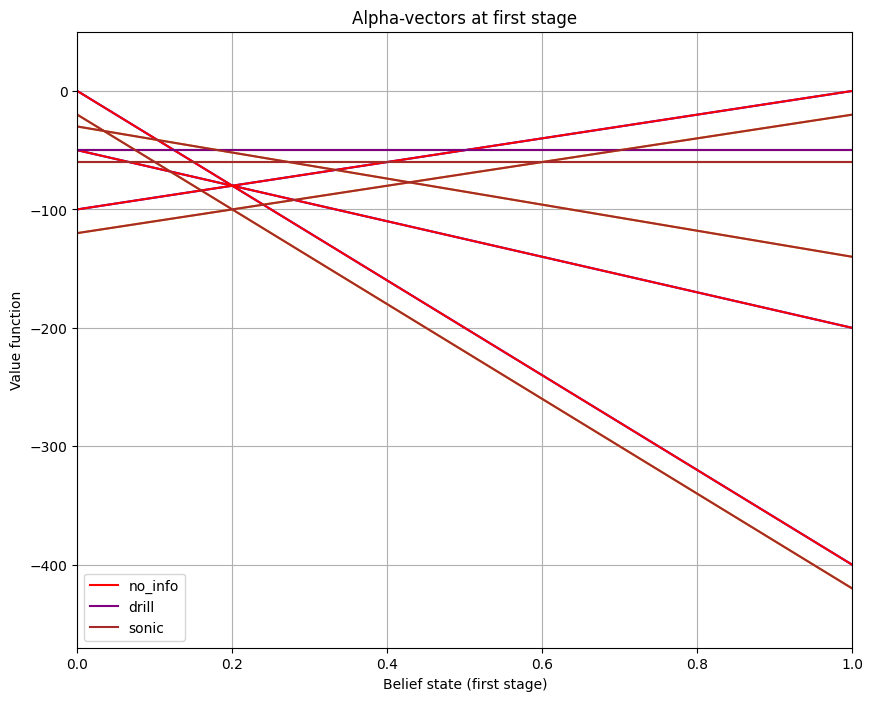

In [15]:
# Plotting the alpha-vectors over the belief simplex (2 states) and color each vector based on its associated action
plt.figure(figsize=(10, 8))
colors = {"order_short_no_info": "blue",
          "order_short_drill": "green",
          "order_short_sonic": "orange",
          "order_long_no_info": "red",
          "order_long_drill": "purple",
          "order_long_sonic": "brown"}

for alpha_vec, action in zip(alpha_vectors_t0, associated_actions):
    plt.plot([0, 1],
             [alpha_vec[0], alpha_vec[1]],
             color=colors[action],
             label=action)

plt.title("Alpha-vectors at first stage")
plt.xlabel("Belief state (first stage)")
plt.ylabel("Value function")
plt.xlim(0, 1)
plt.ylim(min(alpha_vectors_t0.flatten()) - 50,
         max(alpha_vectors_t0.flatten()) + 50)
plt.grid()

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()

def clean_label(label):
    return label.replace("order_short_", "").replace("order_long_", "")

by_label = {}
for label, handle in zip(labels, handles):
    by_label[clean_label(label)] = handle

plt.legend(by_label.values(), by_label.keys())
plt.show()

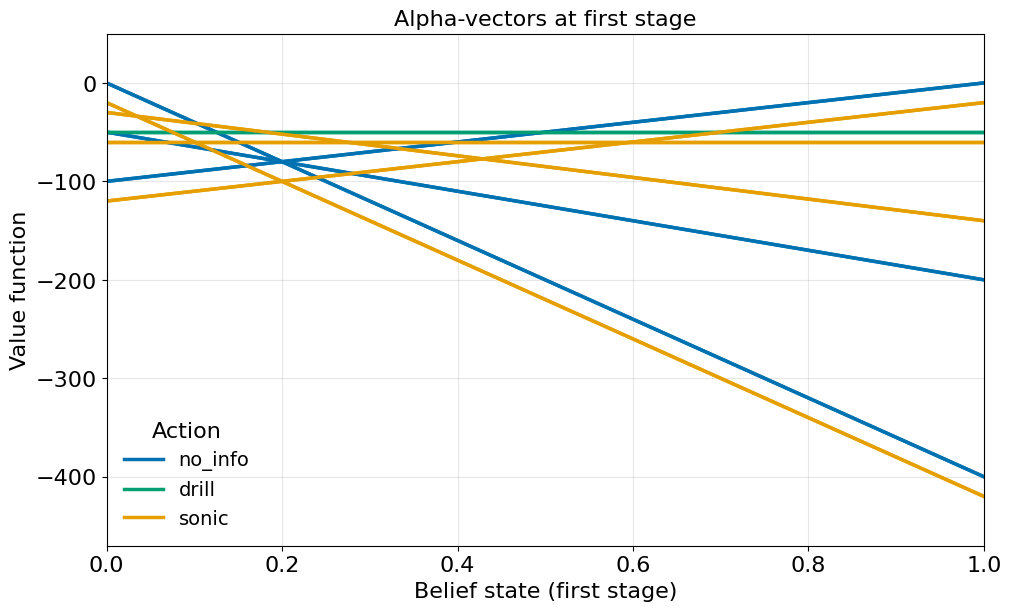

In [23]:
import matplotlib.pyplot as plt

# --- Global style (font size 16 everywhere) ---
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,   # slightly smaller so it doesn't dominate
})

# Colorblind-friendly (Okabe–Ito palette)
colors = {
    "order_short_no_info": "#0072B2",   # blue
    "order_short_drill":   "#009E73",   # bluish green
    "order_short_sonic":   "#E69F00",   # orange
    "order_long_no_info":  "#0072B2",   # sky blue
    "order_long_drill":    "#009E73",   # reddish purple
    "order_long_sonic":    "#E69F00",   # vermillion
}

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

for alpha_vec, action in zip(alpha_vectors_t0, associated_actions):
    ax.plot([0, 1],
            [alpha_vec[0], alpha_vec[1]],
            color=colors.get(action, "black"),
            linewidth=2.5,
            label=action)

ax.set_title("Alpha-vectors at first stage")
ax.set_xlabel("Belief state (first stage)")
ax.set_ylabel("Value function")
ax.set_xlim(0, 1)
ax.set_ylim(min(alpha_vectors_t0.flatten()) - 50,
            max(alpha_vectors_t0.flatten()) + 50)
ax.grid(True, alpha=0.3)

# --- Deduplicate legend labels after cleaning ---
handles, labels = ax.get_legend_handles_labels()

def clean_label(label):
    return label.replace("order_short_", "").replace("order_long_", "")

by_label = {}
for h, lab in zip(handles, labels):
    by_label.setdefault(clean_label(lab), h)  # keep first occurrence

ax.legend(by_label.values(), by_label.keys(), frameon=False, title="Action")

# --- Save as PDF (vector format, crisp in papers) ---
fig.savefig("alpha_vectors_t0.pdf", bbox_inches="tight")

plt.show()


In [17]:
# Stack alpha-vectors for plotting
alpha_vectors_t1 = np.array(alpha_vectors_t1)
print("Shape of alpha-vectors at timestep 1:", alpha_vectors_t1.shape) # (num_vectors, 2 states)
# Summary
print("\nSummary of alpha-vectors at timestep 1 and their associated actions:")
for i, (alpha_vec, action) in enumerate(zip(alpha_vectors_t1, associated_actions_t1)):
    print(f"Alpha-vector {i}: {alpha_vec}, Action: {action}")

Shape of alpha-vectors at timestep 1: (2, 2)

Summary of alpha-vectors at timestep 1 and their associated actions:
Alpha-vector 0: [   0. -400.], Action: order_short_no_info
Alpha-vector 1: [-100.    0.], Action: order_long_no_info


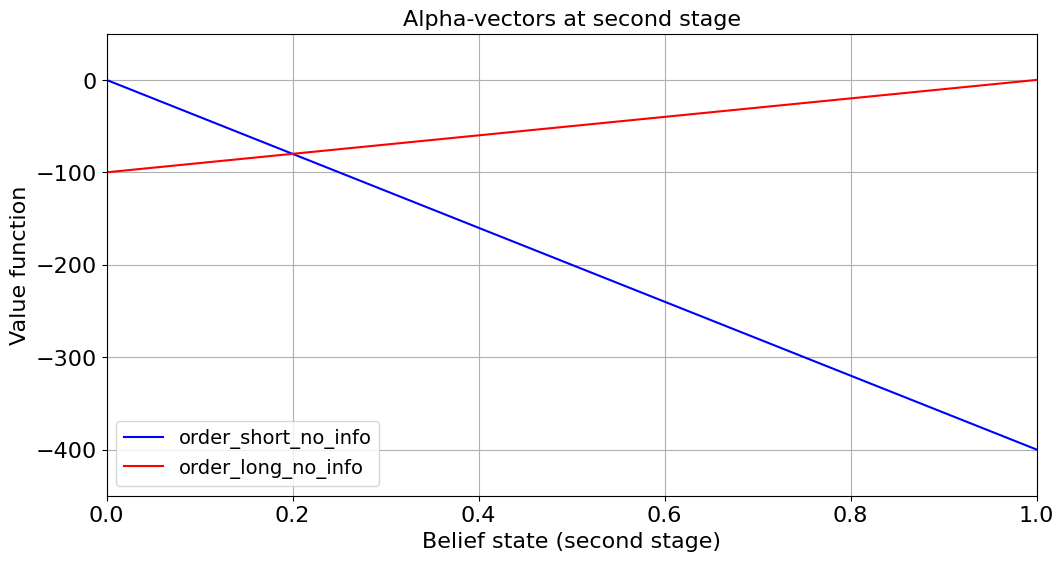

In [21]:
# Plotting the alpha-vectors over the belief simplex (2 states) and color each vector based on its associated action at timestep 1
plt.figure(figsize=(12, 6))
colors = {"order_short_no_info": "blue",
          "order_short_drill": "green",
          "order_short_sonic": "orange",
          "order_long_no_info": "red",
          "order_long_drill": "purple",
          "order_long_sonic": "brown"}

for alpha_vec, action in zip(alpha_vectors_t1, associated_actions_t1):
    plt.plot([0, 1],
             [alpha_vec[0], alpha_vec[1]],
             color=colors[action],
             label=action)

plt.title("Alpha-vectors at second stage")
plt.xlabel("Belief state (second stage)")
plt.ylabel("Value function")
plt.xlim(0, 1)
plt.ylim(min(alpha_vectors_t1.flatten()) - 50,
         max(alpha_vectors_t1.flatten()) + 50)
plt.grid()

# Remove duplicate labels
handles, labels = plt.gca().get_legend_handles_labels()

by_label = {}
for label, handle in zip(labels, handles):
    by_label[label] = handle
plt.legend(by_label.values(), by_label.keys())
plt.show()

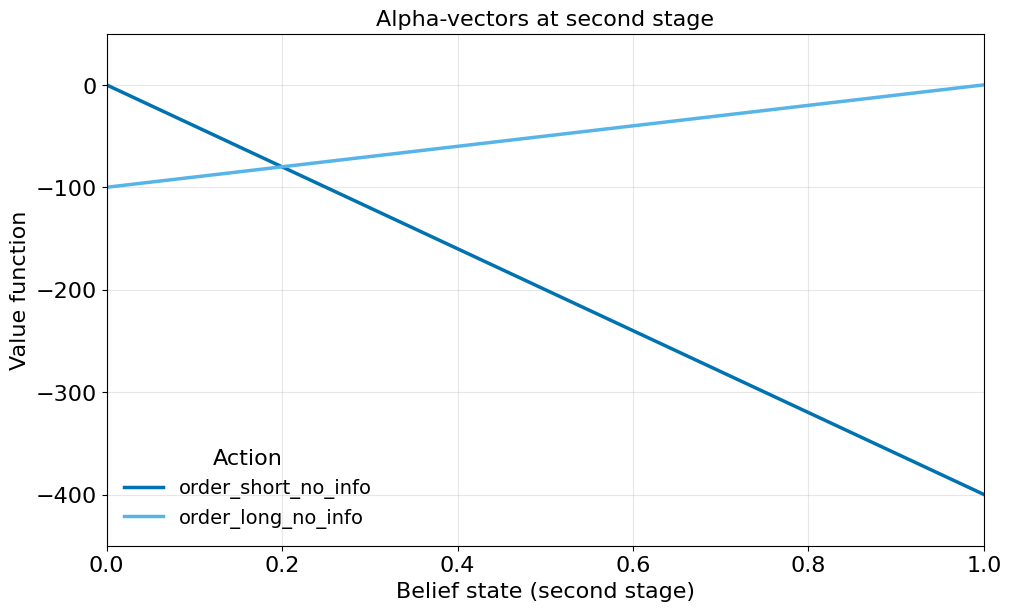

In [25]:
import matplotlib.pyplot as plt

# --- Global style (font size 16 everywhere) ---
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,   # slightly smaller so legend stays tidy
})

# Colorblind-friendly (Okabe–Ito palette)
colors = {
    "order_short_no_info": "#0072B2",   # blue
    "order_short_drill":   "#009E73",   # bluish green
    "order_short_sonic":   "#E69F00",   # orange
    "order_long_no_info":  "#56B4E9",   # sky blue
    "order_long_drill":    "#CC79A7",   # reddish purple
    "order_long_sonic":    "#D55E00",   # vermillion
}

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

for alpha_vec, action in zip(alpha_vectors_t1, associated_actions_t1):
    ax.plot([0, 1],
            [alpha_vec[0], alpha_vec[1]],
            color=colors.get(action, "black"),
            linewidth=2.5,
            label=action)

ax.set_title("Alpha-vectors at second stage")
ax.set_xlabel("Belief state (second stage)")
ax.set_ylabel("Value function")
ax.set_xlim(0, 1)
ax.set_ylim(min(alpha_vectors_t1.flatten()) - 50,
            max(alpha_vectors_t1.flatten()) + 50)
ax.grid(True, alpha=0.3)

# --- Deduplicate legend labels ---
handles, labels = ax.get_legend_handles_labels()
by_label = {}
for h, lab in zip(handles, labels):
    by_label.setdefault(lab, h)   # keep first occurrence

ax.legend(by_label.values(), by_label.keys(), frameon=False, title="Action")

# --- Save as PDF ---
fig.savefig("alpha_vectors_t1.pdf", bbox_inches="tight")

plt.show()